# Pós-Tech FIAP — IA para Devs (9IADT)
## Tech Challenge — Fase 2
### Projeto 1: otimização de modelos de diagnóstico

| Aluno | RM |
| :--- | :--- |
| Antonio Bazo | 372646 |
| Renato Mattos | 370975 |
| Vinicius Geisler | 373670 |
| Marcelo Costa | 371714 |
| Vinicius Blasque | 370746 |

Neste trabalho, continuamos o sistema de diagnóstico de câncer de mama da Fase 1. Nosso objetivo foi usar um Algoritmo Genético (AG) para otimizar os hiperparâmetros de um Random Forest e comparar o resultado com o mesmo modelo em sua configuração padrão. Também conectamos o modelo à aplicação Streamlit, que apresenta explicações locais com SHAP e permite solicitar uma interpretação em linguagem natural ao Gemini.

> O sistema é uma demonstração acadêmica de apoio computacional. Ele não substitui avaliação, diagnóstico ou conduta médica.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Execute o notebook dentro do repositório do projeto.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve

from tech_challenge.ag_study import (
    EXPERIMENTS, FITNESS_FORMULA, GENE_SPACE, RF_BASELINE_CONFIG, prepare_data, run_study
)
from tech_challenge.diagnosis import DiagnosisModule

print(f'Raiz do projeto: {PROJECT_ROOT}')

Raiz do projeto: /workspaces/9IADT-tech-challenge


## 1. Dados e preparação

Usamos o `dataset` Breast Cancer Wisconsin (Diagnostic), disponível no scikit-learn. Ele possui 569 amostras e 30 `features` calculadas a partir de imagens digitalizadas de punções de mama.

No `dataset` original, a classe 1 representa casos benignos. Invertemos o alvo para trabalhar com `1 = maligno` e `0 = benigno`, pois o `recall` da classe maligna é uma das métricas que queremos priorizar. Separamos 80% dos dados para treino e 20% para teste com estratificação. O `StandardScaler` foi ajustado somente no treino, evitando `data leakage`. Embora o Random Forest não dependa de padronização, mantivemos esse passo para preservar o contrato de inferência usado pela aplicação.

In [2]:
data = prepare_data()
print(f'Dataset: {data.x.shape[0]} amostras e {data.x.shape[1]} features')
print(f'Treino: {data.x_train.shape} | Teste: {data.x_test.shape}')
print(f'Classes no treino: {data.y_train.value_counts().to_dict()}')
data.x.head()

Dataset: 569 amostras e 30 features
Treino: (455, 30) | Teste: (114, 30)
Classes no treino: {0: 285, 1: 170}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Random Forest baseline e representação genética

O `baseline` é um Random Forest com os parâmetros padrão mais relevantes explicitados no código. No AG, cada indivíduo representa uma configuração do mesmo algoritmo. Assim, a comparação mede o efeito da otimização de hiperparâmetros, sem misturar a troca de família de modelo.

O cromossomo contém `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` e `class_weight`. Implementamos seleção por torneio, `crossover` uniforme, mutação por substituição de um gene e elitismo com os dois melhores indivíduos.

A função usada na validação cruzada é `fitness = 0,6 × F1 + 0,4 × recall`. O F1 equilibra `precision` e `recall`, enquanto o peso adicional do `recall` reflete o custo de deixar um caso maligno sem detecção.

In [3]:
print('Random Forest baseline:')
display(pd.Series(RF_BASELINE_CONFIG, name='valor').to_frame())
print(f'\nFitness: {FITNESS_FORMULA}')
print('\nEspaço genético:')
display(pd.Series(GENE_SPACE, name='valores').to_frame())
print('\nExperimentos:')
display(pd.DataFrame(EXPERIMENTS))

Random Forest baseline:


,valor
n_estimators,100
max_depth,None
min_samples_split,2
min_samples_leaf,1
max_features,sqrt
class_weight,None



Fitness: 0.6 * f1 + 0.4 * recall

Espaço genético:


,valores
n_estimators,"[50, 100, 200, 300]"
max_depth,"[4, 8, 12, 16, None]"
min_samples_split,"[2, 5, 10]"
min_samples_leaf,"[1, 2, 4]"
max_features,"[sqrt, log2, 0.5]"
class_weight,"[None, balanced]"



Experimentos:


,name,population,generations,mutation_rate
0,Exp1_Referencia,15,15,0.1
1,Exp2_Populacao_Maior,30,15,0.1
2,Exp3_Mutacao_Maior,30,15,0.3


## 3. Experimentos evolutivos

Executamos três configurações com a mesma semente base e os mesmos três `folds` estratificados. Do primeiro para o segundo experimento, alteramos somente o tamanho da população. Do segundo para o terceiro, alteramos somente a taxa de mutação. Com isso, conseguimos interpretar melhor o efeito de cada mudança.

O melhor experimento é escolhido pelo maior `fitness` de validação cruzada. Somente depois dessa escolha avaliamos o modelo vencedor no conjunto de teste. A célula abaixo também exporta o modelo e o JSON consumido pela API e pelo Streamlit.

In [4]:
study = run_study(verbose=True)
data = study['data']
artifact = study['artifact']
print(f"\nVencedor: {artifact['best_experiment']}")
print(f"Configuração: {artifact['best_config']}")
print(f"Modelo salvo em: {study['model_path']}")
print(f"Resultados salvos em: {study['results_path']}")


--- Exp1_Referencia ---


Geração 00 | melhor=0.9401 | média=0.9314


Geração 01 | melhor=0.9446 | média=0.9364


Geração 02 | melhor=0.9446 | média=0.9383


Geração 03 | melhor=0.9446 | média=0.9393


...

Geração 04 | melhor=0.9505 | média=0.9431
Geração 05 | melhor=0.9505 | média=0.9487


Geração 06 | melhor=0.9505 | média=0.9475


Geração 07 | melhor=0.9505 | média=0.9482


Geração 08 | melhor=0.9505 | média=0.9496


Geração 09 | melhor=0.9505 | média=0.9475
Geração 10 | melhor=0.9505 | média=0.9495
Geração 11 | melhor=0.9505 | média=0.9488
Geração 12 | melhor=0.9505 | média=0.9472
Geração 13 | melhor=0.9505 | média=0.9483
Geração 14 | melhor=0.9505 | média=0.9481

Vencedor: Exp3_Mutacao_Maior
Configuração: {'n_estimators': 50, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}
Modelo salvo em: /workspaces/9IADT-tech-challenge/model/best_model.pkl
Resultados salvos em: /workspaces/9IADT-tech-challenge/results/ag_experiment_results.json


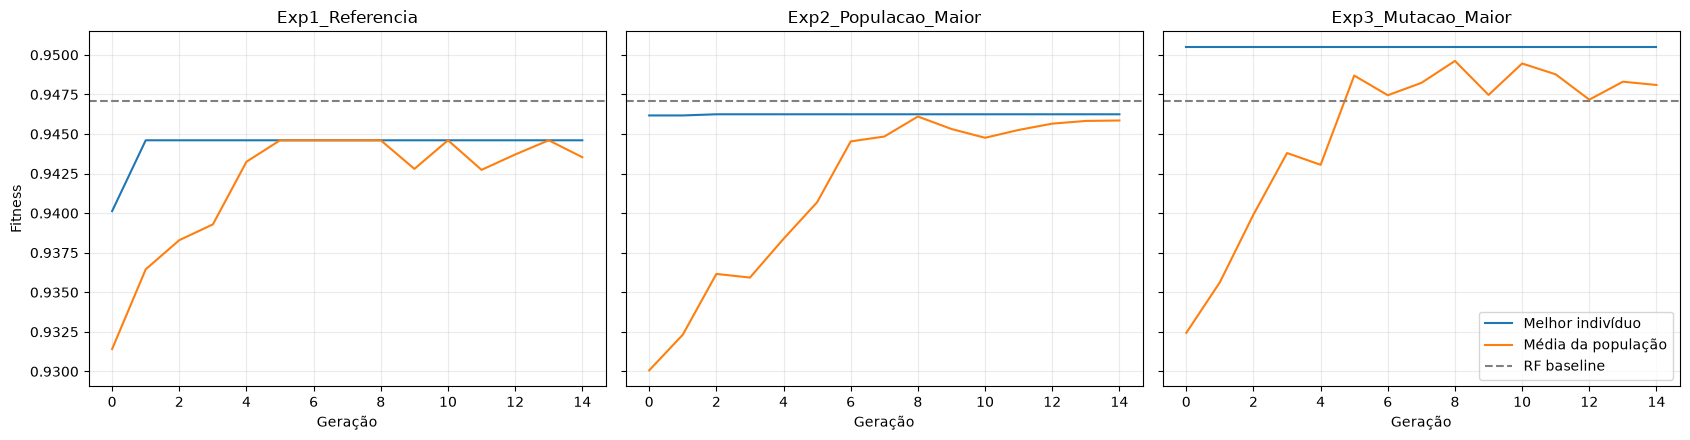

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for axis, experiment in zip(axes, artifact['experiments']):
    history = experiment['history']
    axis.plot(history['generation'], history['best'], label='Melhor indivíduo')
    axis.plot(history['generation'], history['mean'], label='Média da população')
    axis.axhline(artifact['baseline']['cv_fitness'], color='gray', linestyle='--', label='RF baseline')
    axis.set_title(experiment['name'])
    axis.set_xlabel('Geração')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Fitness')
axes[-1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Avaliação final no conjunto de teste

Depois de selecionar o vencedor pela validação cruzada, treinamos o RF baseline e o RF otimizado com todo o conjunto de treino. A comparação abaixo usa o conjunto de teste apenas nesta etapa final. Além das métricas tradicionais, observamos a matriz de confusão e a quantidade de falsos negativos, que representam casos malignos classificados como benignos.

O terceiro experimento obteve o maior `fitness` de validação (`0,9505`), pouco acima do baseline (`0,9471`). No teste, os dois modelos produziram as mesmas classes: F1 de `0,9630`, `recall` de `0,9286` e três falsos negativos. O ganho apareceu somente no ROC AUC, que passou de `0,9929` para `0,9940`. Portanto, neste recorte, o AG encontrou uma configuração menor, com 50 árvores, mas não melhorou a decisão no limiar padrão.

In [6]:
final = artifact['final_comparison']
comparison = pd.DataFrame({
    'RF baseline': final['baseline']['metrics'],
    'RF otimizado': final['optimized']['metrics'],
}).T
comparison['falsos_negativos'] = [
    final['baseline']['false_negatives'], final['optimized']['false_negatives']
]
display(comparison.round(4))
print('Diferenças do modelo otimizado em relação ao baseline:')
display(pd.Series(final['delta'], name='diferença').to_frame().round(4))

,accuracy,precision,recall,f1,roc_auc,falsos_negativos
RF baseline,0.9737,1.0,0.9286,0.963,0.9929,3
RF otimizado,0.9737,1.0,0.9286,0.963,0.9940,3


Diferenças do modelo otimizado em relação ao baseline:


,diferença
f1,0.0
recall,0.0
false_negative_reduction,0.0


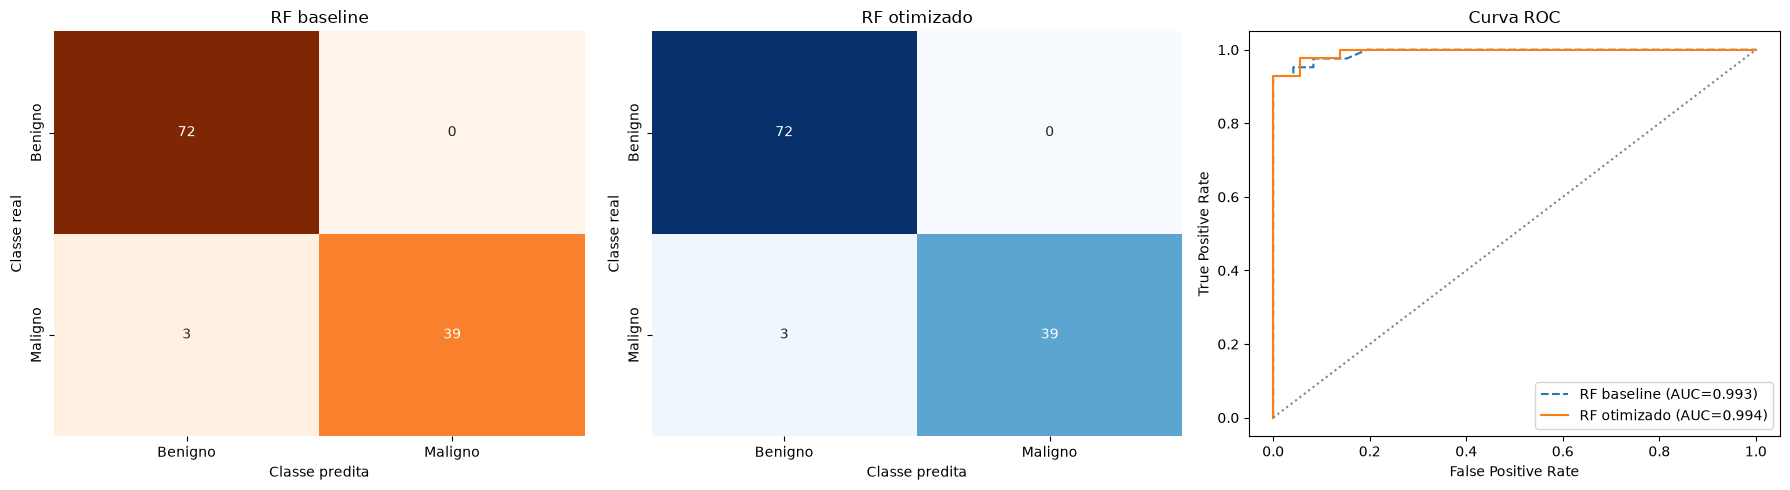

In [7]:
baseline_test = study['baseline_test']
optimized_test = study['optimized_test']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, result, title, color in [
    (axes[0], baseline_test, 'RF baseline', 'Oranges'),
    (axes[1], optimized_test, 'RF otimizado', 'Blues'),
]:
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap=color, cbar=False, ax=axis,
                xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
    axis.set_title(title)
    axis.set_xlabel('Classe predita')
    axis.set_ylabel('Classe real')
for result, label, style in [(baseline_test, 'RF baseline', '--'), (optimized_test, 'RF otimizado', '-')]:
    fpr, tpr, _ = roc_curve(data.y_test, result['probability'])
    axes[2].plot(fpr, tpr, style, label=f"{label} (AUC={result['metrics']['roc_auc']:.3f})")
axes[2].plot([0, 1], [0, 1], ':', color='gray')
axes[2].set_title('Curva ROC')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
plt.tight_layout()
plt.show()

## 5. Análise exploratória por tamanho do tumor

Como o `dataset` não possui informações demográficas, não é possível realizar uma análise de fairness entre grupos de pessoas. Em vez disso, fizemos uma análise exploratória do `recall` em duas faixas definidas pela mediana de `mean radius` no treino. Essa comparação ajuda a observar o comportamento do modelo em tumores menores e maiores, mas não representa uma medida de equidade demográfica.

In [8]:
subgroup = artifact['subgroup_analysis']
print(f"Mediana de mean radius no treino: {subgroup['training_median']:.4f}")
display(pd.DataFrame({'recall': subgroup['recall'], 'amostras': subgroup['sample_count']}))

Mediana de mean radius no treino: 13.3400


,recall,amostras
maior_que_mediana,0.925,58
menor_ou_igual_mediana,1.000,56


## 6. Explicabilidade com SHAP

Usamos SHAP para calcular contribuições locais das `features` no Random Forest otimizado. A aplicação reutiliza essas mesmas contribuições no gráfico do paciente e no contexto enviado à LLM. Assim, não confundimos um valor padronizado alto com influência real na predição.

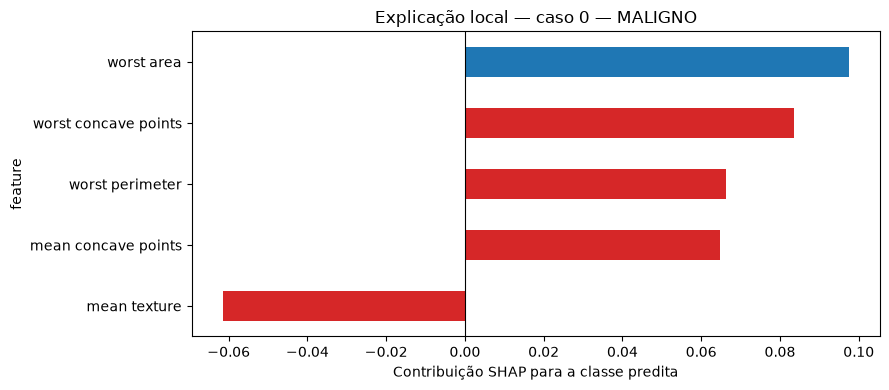

,feature,value,impact
0,worst area,2019.0000,0.097453
1,worst concave points,0.2654,0.083629
2,worst perimeter,184.6000,0.066223
3,mean concave points,0.1471,0.064782
4,mean texture,10.3800,-0.061458


In [9]:
diagnosis_module = DiagnosisModule()
example = diagnosis_module.diagnose_patient(0)
impact_frame = pd.DataFrame([vars(feature) for feature in example.top_features])
colors = ['#d62728' if value > 0 else '#1f77b4' for value in impact_frame['impact']]
ax = impact_frame.sort_values('impact').plot.barh(x='feature', y='impact', color=colors, legend=False, figsize=(9, 4))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f"Explicação local — caso 0 — {example.prediction}")
ax.set_xlabel('Contribuição SHAP para a classe predita')
plt.tight_layout()
plt.show()
display(impact_frame)

## 7. Aplicação, LLM e avaliação das explicações

A demonstração foi separada do estudo: o notebook gera os artefatos, a API FastAPI oferece diagnóstico e explicação, e o Streamlit apresenta os resultados. Quando selecionamos um paciente, a API carrega o RF otimizado, calcula a predição e os impactos SHAP e envia esse contexto ao Gemini 2.5 Flash. Os prompts ficam versionados em `src/tech_challenge/llm/prompts.py` e exigem JSON, aviso médico e validação profissional.

A qualidade pode ser avaliada na própria tela. Fazemos verificações automáticas de estrutura, presença do aviso, coerência com a classe e referência às `features` SHAP. Também disponibilizamos notas humanas de clareza, coerência, segurança e utilidade, persistidas apenas localmente. Essa avaliação é qualitativa e não substitui validação clínica.

## 8. Execução local

A solução roda localmente com `docker compose up --build`. O Compose inicia a API na porta 8000 e o Streamlit na porta 8501, aguarda o `health check` e compartilha a pasta de resultados. A chave `GEMINI_API_KEY` é opcional para os diagnósticos e necessária somente para gerar explicações. Os logs registram rota, status e duração, sem armazenar dados do paciente.

# Conclusão

Neste projeto, implementamos os operadores fundamentais de um Algoritmo Genético e os usamos para otimizar somente o Random Forest. Os três experimentos foram desenhados para variar um fator de cada vez, e escolhemos o vencedor pela validação cruzada antes de consultar o conjunto de teste. Isso tornou a comparação com o baseline mais direta e reduziu o risco de selecionar uma configuração favorecida pelo teste.

O modelo otimizado apresentou um pequeno aumento no ROC AUC, mas manteve F1, `recall` e falsos negativos iguais aos do baseline. Esse resultado é importante porque mostra que a otimização não garante melhora em todas as métricas, principalmente em um conjunto de teste pequeno.

Também conectamos o resultado à aplicação local. O JSON exibido pelo Streamlit é exportado pelo mesmo estudo que salva o modelo, e as explicações usam impactos SHAP do modelo final. Como limitações, trabalhamos com um `dataset` pequeno, sem variáveis demográficas e sem validação externa. Os resultados não permitem uso clínico real; servem apenas para demonstrar otimização evolutiva, explicabilidade e integração com uma LLM.